## ASSIGNMENT 1
## NAME: MEGHA RAJEEV 
## REG NO: 23MIM10047

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## DATA LOADING

In [3]:
insurance = pd.read_csv("insurance.csv")

## DATA UNDERSTANDING

In [5]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
insurance.shape

(1338, 7)

In [7]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
insurance.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [11]:
numerical_features = insurance.select_dtypes(include=['int64', 'float64']).columns

print(numerical_features)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


In [12]:
categorical_features = insurance.select_dtypes(include=['object']).columns

print(categorical_features)

Index(['sex', 'smoker', 'region'], dtype='object')


In [13]:
target = "charges"

print("Target Variable:", target)

Target Variable: charges


In [14]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
insurance.duplicated().sum()

np.int64(1)

In [16]:
insurance.drop_duplicates(inplace=True)

In [18]:
insurance.sample(5, random_state=42)

,age,sex,bmi,children,smoker,region,charges
900,49,male,22.515,0,no,northeast,8688.85885
1064,29,female,25.600,4,no,southwest,5708.86700
1256,51,female,36.385,3,no,northwest,11436.73815
298,31,male,34.390,3,yes,northwest,38746.35510
237,31,male,38.390,2,no,southeast,4463.20510


## Data Understanding Summary
The dataset contains 1338 customer records with 7 features, including demographic and health-related information. There are 4 numerical features (age, bmi, children, charges) and 3 categorical features (sex, smoker, region). The target variable is charges, representing the medical insurance cost. The dataset has no missing values, and the categorical variables will require encoding before model training.


## EXPLORATORY DATA ANALYSIS (EDA)

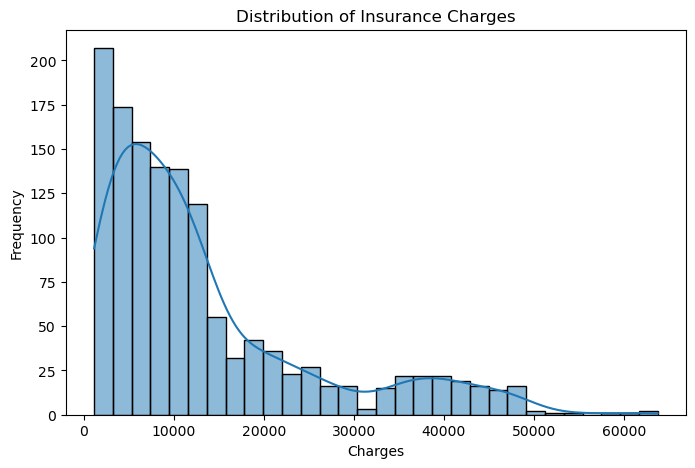

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(insurance['charges'], bins=30, kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

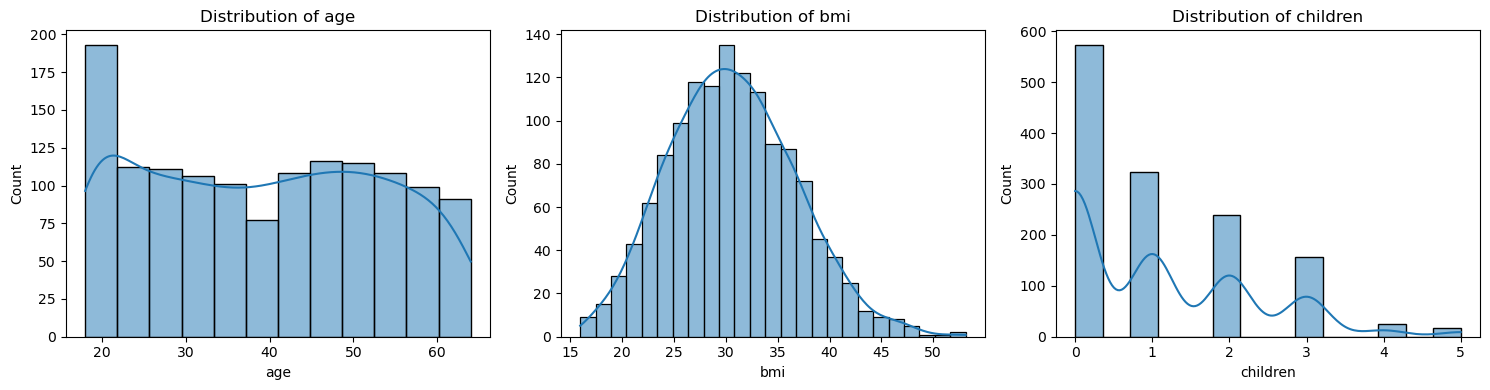

In [22]:
num_features = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, feature in enumerate(num_features):
    sns.histplot(insurance[feature], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

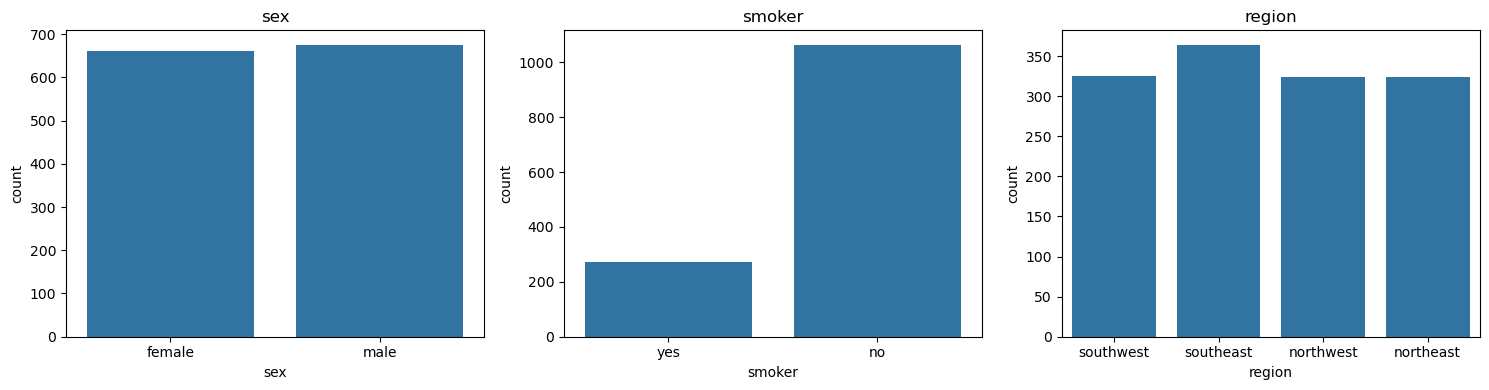

In [24]:
cat_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1,3, figsize=(15,4))

for i, feature in enumerate(cat_features):
    sns.countplot(data=insurance, x=feature, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

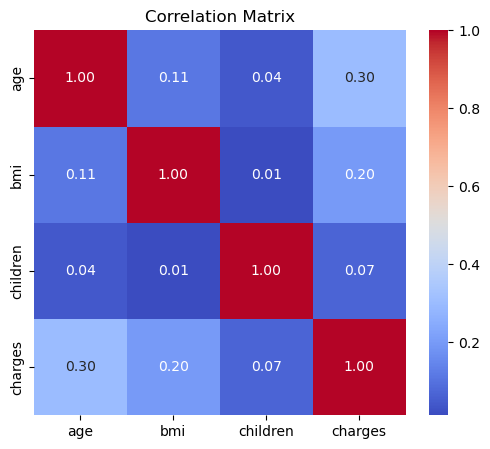

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(
    insurance.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

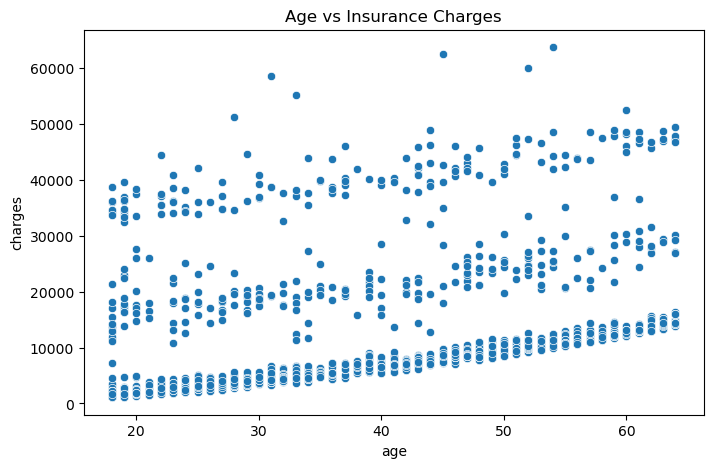

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=insurance,
    x="age",
    y="charges"
)

plt.title("Age vs Insurance Charges")

plt.show()

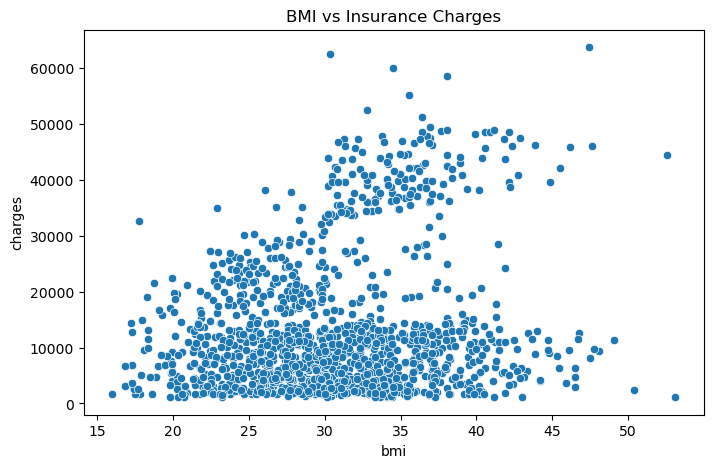

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=insurance,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Insurance Charges")

plt.show()

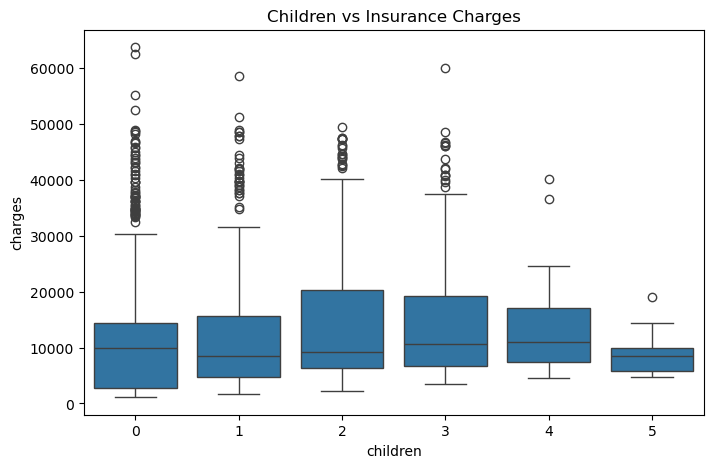

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=insurance,
    x="children",
    y="charges"
)

plt.title("Children vs Insurance Charges")

plt.show()

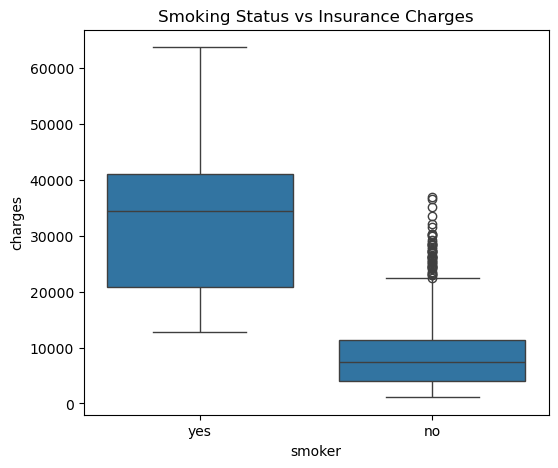

In [37]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=insurance,
    x="smoker",
    y="charges"
)

plt.title("Smoking Status vs Insurance Charges")

plt.show()

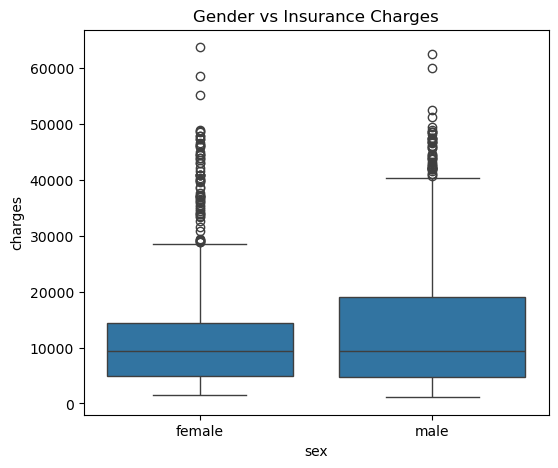

In [30]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=insurance,
    x="sex",
    y="charges"
)

plt.title("Gender vs Insurance Charges")

plt.show()

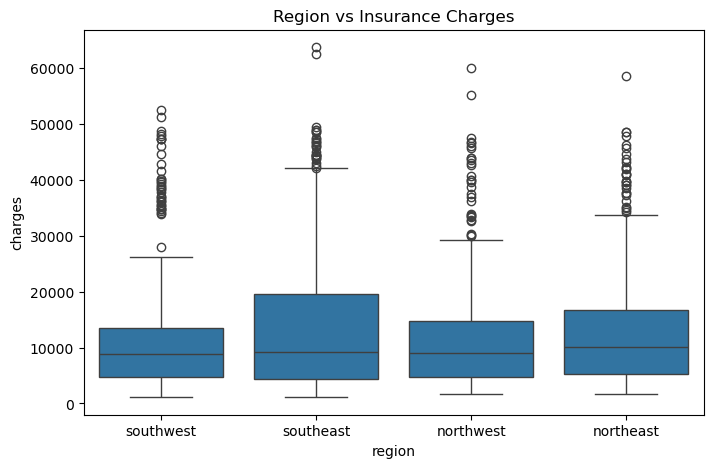

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=insurance,
    x="region",
    y="charges"
)

plt.title("Region vs Insurance Charges")

plt.show()

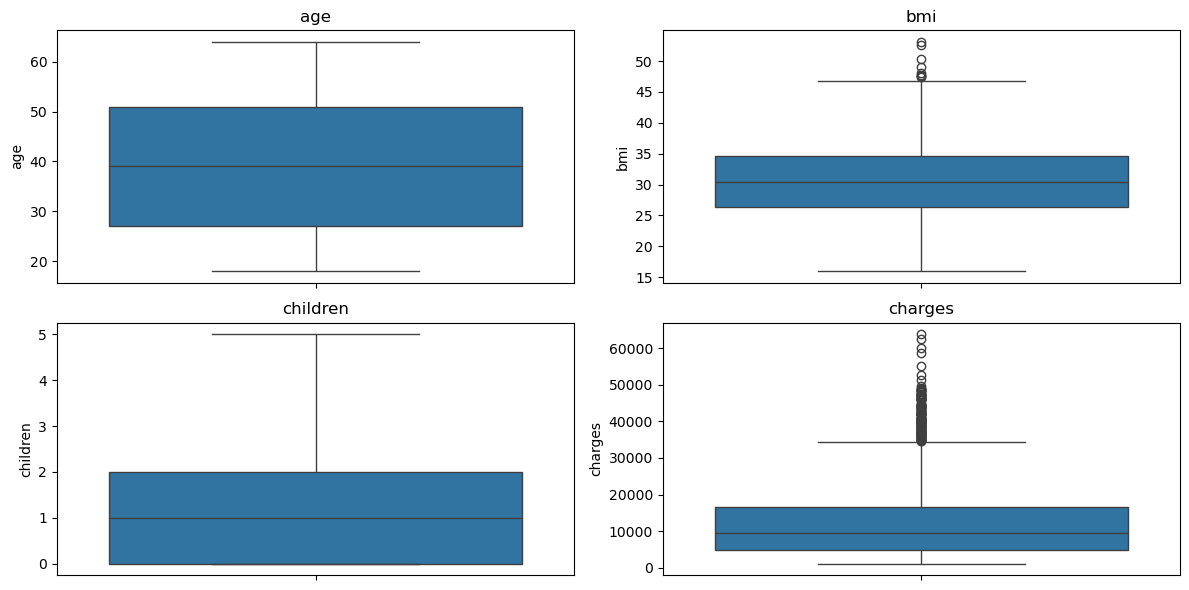

In [32]:
num_features = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(12,6))

for i, feature in enumerate(num_features):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=insurance[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

## EDA Summary
The exploratory data analysis revealed that insurance charges are positively skewed, with a small number of customers incurring very high medical expenses. Among the numerical variables, age showed the strongest positive correlation with charges, followed by BMI, while the number of children had minimal influence. The box plots demonstrated that smokers have significantly higher insurance charges than non-smokers, making smoking status one of the most important predictive features. Gender and region showed relatively small differences in insurance costs. Although outliers are present in the charges feature, they likely represent genuine observations and were retained for model development.


## DATA PREPROCESSING

In [33]:
# Check duplicate records
print("Duplicate Rows:", insurance.duplicated().sum())

Duplicate Rows: 0


In [34]:
# One-Hot Encoding
insurance_encoded = pd.get_dummies(insurance, columns=['sex', 'smoker', 'region'], drop_first=True)

In [35]:
insurance_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [39]:
# Features (Independent Variables)
X = insurance_encoded.drop("charges", axis=1)

# Target (Dependent Variable)
y = insurance_encoded["charges"]

In [40]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1337, 8)
Target Shape: (1337,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1069, 8)
Testing Features: (268, 8)
Training Target: (1069,)
Testing Target: (268,)


## Data Preprocessing Summary
The dataset was prepared for model training by first checking for duplicate records and removing them if present. Categorical variables (sex, smoker, and region) were transformed into numerical features using One-Hot Encoding with drop_first=True to avoid multicollinearity. The encoded dataset was then divided into independent features (X) and the target variable (charges). Finally, the data was split into 80% training and 20% testing sets using train_test_split with a fixed random_state to ensure reproducibility. No feature scaling was applied because Multiple Linear Regression does not require it.

## MODEL DEVELOPMENT

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
# Create the Linear Regression model
model = LinearRegression()

In [45]:
# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


In [47]:
print("Intercept:", model.intercept_)

Intercept: -11092.652295945943


In [48]:
y_pred = model.predict(X_test)

In [49]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## MODEL EVALUATION

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [51]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
R² Score: 0.8069


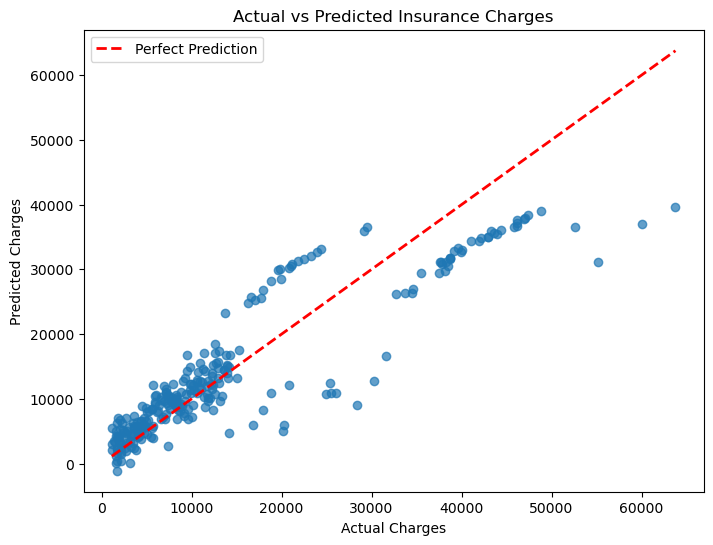

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()

plt.show()

## Observations from Model Evaluation

## Observation 1

The Multiple Linear Regression model achieved an R² score of 0.8069, indicating that it explains approximately 80.69% of the variation in medical insurance charges. This demonstrates good predictive performance.

## Observation 2

The Mean Absolute Error (MAE) of 4177.05 indicates that, on average, the predicted insurance charges differ from the actual values by about 4177 units, which is reasonable given the range of charges in the dataset.

## Observation 3

The Actual vs. Predicted scatter plot shows that most predictions are close to the ideal reference line. However, the model exhibits larger errors for customers with very high insurance charges, suggesting that Multiple Linear Regression has limitations in capturing complex or non-linear relationships.

## CONCLUSION
This project successfully developed a Multiple Linear Regression model to predict medical insurance charges using customer information such as age, sex, BMI, number of children, smoking status, and region. The model achieved an R² score of 0.8069, indicating that it explains approximately 80.69% of the variation in insurance charges and provides good predictive performance. The analysis revealed that smoking status is the most influential factor affecting insurance charges, followed by age and BMI, while gender, region, and the number of children have comparatively smaller effects. The model produced reasonably accurate predictions with a Mean Absolute Error (MAE) of 4177.05. However, one limitation of Multiple Linear Regression is that it assumes a linear relationship between the input features and the target variable, making it less effective at capturing complex or non-linear patterns, particularly for customers with very high insurance charges.
